In [1]:
import numpy as np
from matplotlib import pyplot as plt
import pandas as pd
import pickle
from scipy.stats import norm
from scipy import stats
from statsmodels.stats.anova import AnovaRM
from statsmodels.stats.multicomp import pairwise_tukeyhsd

In [2]:
def to_day(di):
    if di >= 2:
        return "day6"
    else:
        return "day" + str(di + 1)

In [3]:
with open("beh.pkl", "rb") as f:
    beh = pickle.load(f)
with open("h_spike.pkl", "rb") as f:
    h = pickle.load(f)

In [4]:
width = 50
save_50 = []
for mi in range(6):
    save_s = []
    for di in range(3):
        t_h, k = h[mi][di].shape
        t = t_h - 49
        mean = h[mi][di].mean(axis=0)
        std = h[mi][di].std(axis=0)
        succ = np.where(beh[mi][di][:, 2] == 1)[0]
        miss = np.where((beh[mi][di][:, 2] == 0) & (beh[mi][di][:, 1] == 1))[0]
        succ = succ[(succ + 49 >= width) & (succ + width < t)]
        miss = miss[(miss + 49 >= width) & (miss + width < t)]
        n_succ = len(succ)
        n_miss = len(miss)
        tmp = np.zeros((2*width+1, k, 2))
        for i in range(1,width+1):
            tmp[width-i, :, 0] = (h[mi][di][succ+49-i].mean(axis=0) - mean) / std
            tmp[width+i, :, 0] = (h[mi][di][succ+49+i].mean(axis=0) - mean) / std
            tmp[width-i, :, 1] = (h[mi][di][miss+49-i].mean(axis=0) - mean) / std
            tmp[width+i, :, 1] = (h[mi][di][miss+49+i].mean(axis=0) - mean) / std
        tmp[width, :, 0] = (h[mi][di][succ+49].mean(axis=0) - mean) / std
        tmp[width, :, 1] = (h[mi][di][miss+49].mean(axis=0) - mean) / std
        save_s.append(tmp)
    save_50.append(save_s)

In [5]:
width = 100
save_100 = []
for mi in range(6):
    save_s = []
    for di in range(3):
        t_h, k = h[mi][di].shape
        t = t_h - 49
        mean = h[mi][di].mean(axis=0)
        std = h[mi][di].std(axis=0)
        succ = np.where(beh[mi][di][:, 2] == 1)[0]
        miss = np.where((beh[mi][di][:, 2] == 0) & (beh[mi][di][:, 1] == 1))[0]
        succ = succ[(succ + 49 >= width) & (succ + width < t)]
        miss = miss[(miss + 49 >= width) & (miss + width < t)]
        n_succ = len(succ)
        n_miss = len(miss)
        tmp = np.zeros((2*width+1, k, 2))
        for i in range(1,width+1):
            tmp[width-i, :, 0] = (h[mi][di][succ+49-i].mean(axis=0) - mean) / std
            tmp[width+i, :, 0] = (h[mi][di][succ+49+i].mean(axis=0) - mean) / std
            tmp[width-i, :, 1] = (h[mi][di][miss+49-i].mean(axis=0) - mean) / std
            tmp[width+i, :, 1] = (h[mi][di][miss+49+i].mean(axis=0) - mean) / std
        tmp[width, :, 0] = (h[mi][di][succ+49].mean(axis=0) - mean) / std
        tmp[width, :, 1] = (h[mi][di][miss+49].mean(axis=0) - mean) / std
        save_s.append(tmp)
    save_100.append(save_s)

In [6]:
width = 50
corr_50 = []
for mi in range(6):
    corr_s = []
    for di in range(3):
        k = save_50[mi][di].shape[1]
        tmp = np.zeros((k, 2))
        for ki in range(k):
            tmp[ki, 0] = np.corrcoef(save_50[mi][di][:width, ki, :].T)[1, 0]
            tmp[ki, 1] = np.corrcoef(save_50[mi][di][-width:, ki, :].T)[1, 0]
        corr_s.append(tmp)
    corr_50.append(corr_s)

In [7]:
width = 100
corr_100 = []
for mi in range(6):
    corr_s = []
    for di in range(3):
        k = save_100[mi][di].shape[1]
        tmp = np.zeros((k, 2))
        for ki in range(k):
            tmp[ki, 0] = np.corrcoef(save_100[mi][di][:width, ki, :].T)[1, 0]
            tmp[ki, 1] = np.corrcoef(save_100[mi][di][-width:, ki, :].T)[1, 0]
        corr_s.append(tmp)
    corr_100.append(corr_s)

mouse1 day1


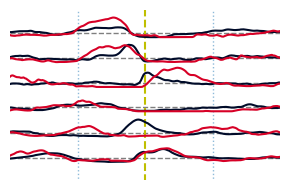

mouse1 day2


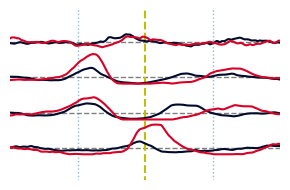

mouse1 day6


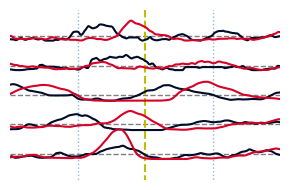

mouse2 day1


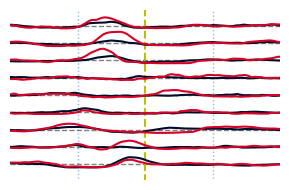

mouse2 day2


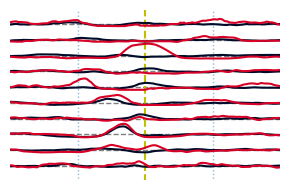

mouse2 day6


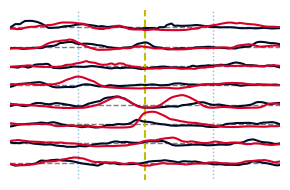

mouse3 day1


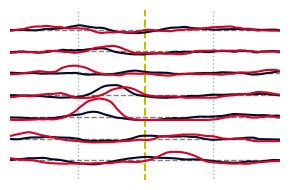

mouse3 day2


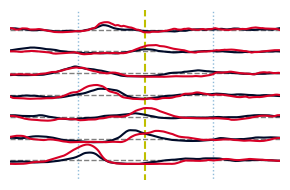

mouse3 day6


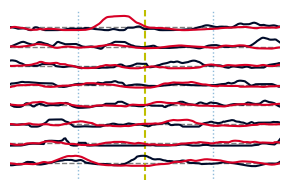

mouse4 day1


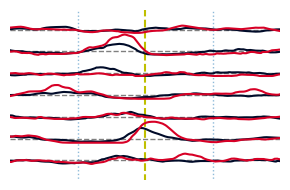

mouse4 day2


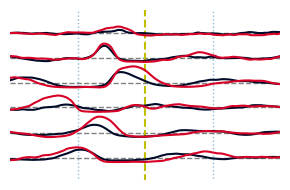

mouse4 day6


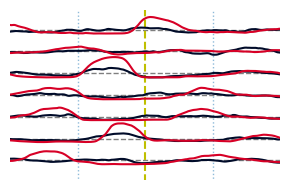

mouse5 day1


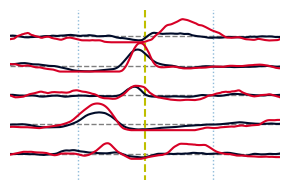

mouse5 day2


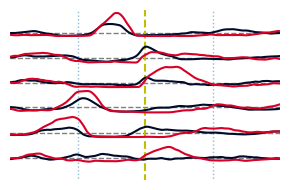

mouse5 day6


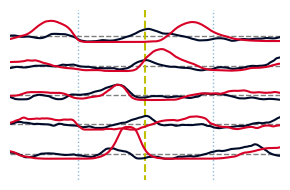

mouse6 day1


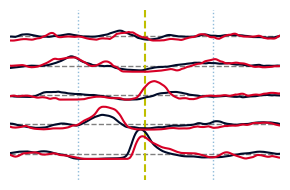

mouse6 day2


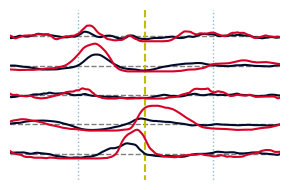

mouse6 day6


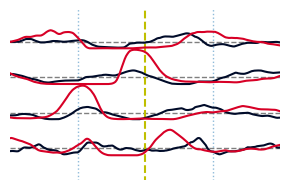

In [8]:
scale = 3
for mi in range(6):
    mouse = "mouse" + str(mi + 1)
    for di in range(3):
        day = to_day(di)
        print(mouse, day)
        tmp = save_100[mi][di].copy()
        tmp[tmp > 5] = 5
        tmp[tmp < -5] = -5
        k = tmp.shape[1]
        plt.figure(figsize=(3, 2))
        for i in range(k):
            for j, color in enumerate(["#d70026", "#000b29"]):
                plt.plot(tmp[:, i, j] - scale*i, c=color, zorder=2-j)
            plt.hlines(-scale*i, 0, 200, color="k", alpha=0.5, zorder=0, linestyles="--", linewidth=1)
        plt.xlim(0, 200)
        plt.yticks([-scale*i for i in range(k)])
        plt.ylim(-scale*(k-0.1), scale * 0.9)
        plt.vlines(100, -scale*k, scale, color="y", linestyles="--", zorder=0)
        plt.vlines(50, -scale*k, scale, color="C0", alpha=0.5, linestyles=":", linewidth=1, zorder=0)
        plt.vlines(150, -scale*k, scale, color="C0", alpha=0.5, linestyles=":", linewidth=1, zorder=0)
        plt.tick_params(labelleft=False, labelbottom=False)
        plt.axis("off")
        plt.tight_layout()
        plt.savefig("figures/fig5/fig5b_{}_{}.png".format(mouse, day))
        plt.show()

In [9]:
corr_day_50 = [np.vstack([corr_50[mi][di] for mi in range(6)]) for di in range(3)]
corr_day_50_pre = [corr_day_50[di][:, 0] for di in range(3)]
corr_day_50_post = [corr_day_50[di][:, 1] for di in range(3)]
corr_day_100 = [np.vstack([corr_100[mi][di] for mi in range(6)]) for di in range(3)]
corr_day_100_pre = [corr_day_100[di][:, 0] for di in range(3)]
corr_day_100_post = [corr_day_100[di][:, 1] for di in range(3)]

day1 (n=39) | Q1-1.5IQR: -0.0528, Q1:  0.5389, Median:  0.8540, Q3:  0.9455, Q3+1.5IQR:  0.9873
day2 (n=38) | Q1-1.5IQR:  0.2949, Q1:  0.6670, Median:  0.8547, Q3:  0.9449, Q3+1.5IQR:  0.9960
day6 (n=37) | Q1-1.5IQR: -0.8310, Q1:  0.0549, Median:  0.3464, Q3:  0.8318, Q3+1.5IQR:  0.9554
one-way ANOVA | F2,111=8.1906, P=0.0005
Multiple Comparison of Means - Tukey HSD, FWER=0.05 
group1 group2 meandiff p-adj   lower   upper  reject
----------------------------------------------------
  Day1   Day2    0.021  0.976 -0.2167  0.2587  False
  Day1   Day6  -0.3446 0.0025 -0.5839 -0.1052   True
  Day2   Day6  -0.3656 0.0013 -0.6065 -0.1247   True
----------------------------------------------------


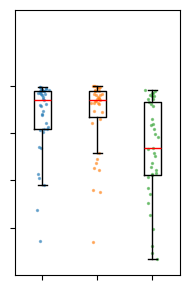

In [10]:
c = corr_day_50_pre
savename = "figures/fig5/fig5f.png"

plt.figure(figsize=(2, 3))
box_data = plt.boxplot(c, sym="", medianprops={"color": "r"})
qs = np.array([d.get_ydata() for d in box_data["whiskers"]]).reshape(-1, 4)
ms = [d.get_ydata()[0] for d in box_data["medians"]]
n = [len(ci) for ci in c]
for i in range(3):
    q1, q1_iqr, q3, q3_iqr = qs[i]
    m = ms[i]
    print("{} (n={}) | Q1-1.5IQR: {:>7.4f}, Q1: {:>7.4f}, Median: {:>7.4f}, Q3: {:>7.4f}, Q3+1.5IQR: {:>7.4f}".format(to_day(i), n[i], q1_iqr, q1, m, q3, q3_iqr))

plt.tick_params(labelleft=False, labelbottom=False)
plt.ylim(-1, 1.8)
plt.yticks([-0.5, 0, 0.5, 1.0])
for i in range(3):
    plt.scatter(np.random.normal(0, 0.05, size=n[i])+i+1, c[i], s=2, alpha=0.5)
plt.tight_layout()
plt.savefig(savename)

f_result = stats.f_oneway(c[0], c[1], c[2])
print("one-way ANOVA | F2,{}={:.4f}, P={:.4f}".format(sum(n)-3, f_result.statistic, f_result.pvalue))

df = pd.DataFrame({
    "corrcoef": np.hstack(c),
    "day": np.hstack((
        ["Day1" for _ in c[0]], 
        ["Day2" for _ in c[1]], 
        ["Day6" for _ in c[2]]))
})
tukey = pairwise_tukeyhsd(endog=df['corrcoef'],
                          groups=df['day'],
                          alpha=0.05)
print(tukey)

day1 (n=39) | Q1-1.5IQR: -0.7075, Q1: -0.1236, Median:  0.3000, Q3:  0.8473, Q3+1.5IQR:  0.9509
day2 (n=38) | Q1-1.5IQR: -0.8790, Q1:  0.0233, Median:  0.5167, Q3:  0.6899, Q3+1.5IQR:  0.9289
day6 (n=37) | Q1-1.5IQR: -0.9425, Q1: -0.4290, Median:  0.0236, Q3:  0.7442, Q3+1.5IQR:  0.9249
one-way ANOVA | F2,111=1.2851, P=0.2807
Multiple Comparison of Means - Tukey HSD, FWER=0.05
group1 group2 meandiff p-adj   lower  upper  reject
---------------------------------------------------
  Day1   Day2    0.009 0.9972 -0.2885 0.3065  False
  Day1   Day6  -0.1716  0.365 -0.4711  0.128  False
  Day2   Day6  -0.1806 0.3326  -0.482 0.1209  False
---------------------------------------------------


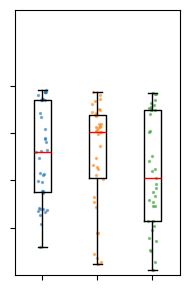

In [11]:
c = corr_day_50_post
savename = "figures/fig5/fig5g.png"

plt.figure(figsize=(2, 3))
box_data = plt.boxplot(c, sym="", medianprops={"color": "r"})
qs = np.array([d.get_ydata() for d in box_data["whiskers"]]).reshape(-1, 4)
ms = [d.get_ydata()[0] for d in box_data["medians"]]
n = [len(ci) for ci in c]
for i in range(3):
    q1, q1_iqr, q3, q3_iqr = qs[i]
    m = ms[i]
    print("{} (n={}) | Q1-1.5IQR: {:>7.4f}, Q1: {:>7.4f}, Median: {:>7.4f}, Q3: {:>7.4f}, Q3+1.5IQR: {:>7.4f}".format(to_day(i), n[i], q1_iqr, q1, m, q3, q3_iqr))

plt.tick_params(labelleft=False, labelbottom=False)
plt.ylim(-1, 1.8)
plt.yticks([-0.5, 0, 0.5, 1.0])
for i in range(3):
    plt.scatter(np.random.normal(0, 0.05, size=n[i])+i+1, c[i], s=2, alpha=0.5)
plt.tight_layout()
plt.savefig(savename)

f_result = stats.f_oneway(c[0], c[1], c[2])
print("one-way ANOVA | F2,{}={:.4f}, P={:.4f}".format(sum(n)-3, f_result.statistic, f_result.pvalue))

df = pd.DataFrame({
    "corrcoef": np.hstack(c),
    "day": np.hstack((
        ["Day1" for _ in c[0]], 
        ["Day2" for _ in c[1]], 
        ["Day6" for _ in c[2]]))
})
tukey = pairwise_tukeyhsd(endog=df['corrcoef'],
                          groups=df['day'],
                          alpha=0.05)
print(tukey)

day1 (n=39) | Q1-1.5IQR: -0.2974, Q1:  0.3771, Median:  0.7145, Q3:  0.8917, Q3+1.5IQR:  0.9699
day2 (n=38) | Q1-1.5IQR:  0.1160, Q1:  0.5665, Median:  0.7895, Q3:  0.9061, Q3+1.5IQR:  0.9717
day6 (n=37) | Q1-1.5IQR: -0.5339, Q1:  0.0889, Median:  0.2881, Q3:  0.7208, Q3+1.5IQR:  0.9192
one-way ANOVA | F2,111=6.6071, P=0.0019
Multiple Comparison of Means - Tukey HSD, FWER=0.05 
group1 group2 meandiff p-adj   lower   upper  reject
----------------------------------------------------
  Day1   Day2   0.0557 0.8024 -0.1534  0.2647  False
  Day1   Day6   -0.249  0.016 -0.4594 -0.0385   True
  Day2   Day6  -0.3047 0.0025 -0.5165 -0.0928   True
----------------------------------------------------


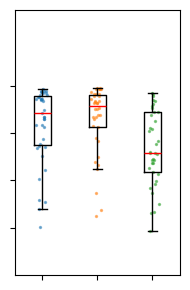

In [12]:
c = corr_day_100_pre
savename = "figures/fig5/fig5d.png"

plt.figure(figsize=(2, 3))
box_data = plt.boxplot(c, sym="", medianprops={"color": "r"})
qs = np.array([d.get_ydata() for d in box_data["whiskers"]]).reshape(-1, 4)
ms = [d.get_ydata()[0] for d in box_data["medians"]]
n = [len(ci) for ci in c]
for i in range(3):
    q1, q1_iqr, q3, q3_iqr = qs[i]
    m = ms[i]
    print("{} (n={}) | Q1-1.5IQR: {:>7.4f}, Q1: {:>7.4f}, Median: {:>7.4f}, Q3: {:>7.4f}, Q3+1.5IQR: {:>7.4f}".format(to_day(i), n[i], q1_iqr, q1, m, q3, q3_iqr))

plt.tick_params(labelleft=False, labelbottom=False)
plt.ylim(-1, 1.8)
plt.yticks([-0.5, 0, 0.5, 1.0])
for i in range(3):
    plt.scatter(np.random.normal(0, 0.05, size=n[i])+i+1, c[i], s=2, alpha=0.5)
plt.tight_layout()
plt.savefig(savename)

f_result = stats.f_oneway(c[0], c[1], c[2])
print("one-way ANOVA | F2,{}={:.4f}, P={:.4f}".format(sum(n)-3, f_result.statistic, f_result.pvalue))

df = pd.DataFrame({
    "corrcoef": np.hstack(c),
    "day": np.hstack((
        ["Day1" for _ in c[0]], 
        ["Day2" for _ in c[1]], 
        ["Day6" for _ in c[2]]))
})
tukey = pairwise_tukeyhsd(endog=df['corrcoef'],
                          groups=df['day'],
                          alpha=0.05)
print(tukey)

day1 (n=39) | Q1-1.5IQR: -0.5950, Q1:  0.0078, Median:  0.4547, Q3:  0.7284, Q3+1.5IQR:  0.9410
day2 (n=38) | Q1-1.5IQR: -0.7607, Q1: -0.1047, Median:  0.1804, Q3:  0.5277, Q3+1.5IQR:  0.9106
day6 (n=37) | Q1-1.5IQR: -0.7856, Q1: -0.2367, Median: -0.0539, Q3:  0.3871, Q3+1.5IQR:  0.8465
one-way ANOVA | F2,111=6.1294, P=0.0030
Multiple Comparison of Means - Tukey HSD, FWER=0.05
group1 group2 meandiff p-adj   lower  upper  reject
---------------------------------------------------
  Day1   Day2  -0.2298  0.064 -0.4702 0.0105  False
  Day1   Day6    -0.35 0.0024 -0.5919 -0.108   True
  Day2   Day6  -0.1201 0.4726 -0.3636 0.1234  False
---------------------------------------------------


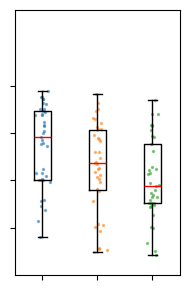

In [13]:
c = corr_day_100_post
savename = "figures/fig5/fig5e.png"

plt.figure(figsize=(2, 3))
box_data = plt.boxplot(c, sym="", medianprops={"color": "r"})
qs = np.array([d.get_ydata() for d in box_data["whiskers"]]).reshape(-1, 4)
ms = [d.get_ydata()[0] for d in box_data["medians"]]
n = [len(ci) for ci in c]
for i in range(3):
    q1, q1_iqr, q3, q3_iqr = qs[i]
    m = ms[i]
    print("{} (n={}) | Q1-1.5IQR: {:>7.4f}, Q1: {:>7.4f}, Median: {:>7.4f}, Q3: {:>7.4f}, Q3+1.5IQR: {:>7.4f}".format(to_day(i), n[i], q1_iqr, q1, m, q3, q3_iqr))

plt.tick_params(labelleft=False, labelbottom=False)
plt.ylim(-1, 1.8)
plt.yticks([-0.5, 0, 0.5, 1.0])
for i in range(3):
    plt.scatter(np.random.normal(0, 0.05, size=n[i])+i+1, c[i], s=2, alpha=0.5)
plt.tight_layout()
plt.savefig(savename)

f_result = stats.f_oneway(c[0], c[1], c[2])
print("one-way ANOVA | F2,{}={:.4f}, P={:.4f}".format(sum(n)-3, f_result.statistic, f_result.pvalue))

df = pd.DataFrame({
    "corrcoef": np.hstack(c),
    "day": np.hstack((
        ["Day1" for _ in c[0]], 
        ["Day2" for _ in c[1]], 
        ["Day6" for _ in c[2]]))
})
tukey = pairwise_tukeyhsd(endog=df['corrcoef'],
                          groups=df['day'],
                          alpha=0.05)
print(tukey)

day1
Pre  (n=39) | Q1-1.5IQR: -0.2974, Q1:  0.3771, Median:  0.7145, Q3:  0.8917, Q3+1.5IQR:  0.9699
Post (n=39) | Q1-1.5IQR: -0.5950, Q1:  0.0078, Median:  0.4547, Q3:  0.7284, Q3+1.5IQR:  0.9410
t-test rel | t38=3.2198, P=0.0026


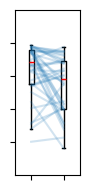

day2
Pre  (n=38) | Q1-1.5IQR:  0.1160, Q1:  0.5665, Median:  0.7895, Q3:  0.9061, Q3+1.5IQR:  0.9717
Post (n=38) | Q1-1.5IQR: -0.7607, Q1: -0.1047, Median:  0.1804, Q3:  0.5277, Q3+1.5IQR:  0.9106
t-test rel | t37=7.4315, P=0.0000


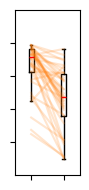

day6
Pre  (n=37) | Q1-1.5IQR: -0.5339, Q1:  0.0889, Median:  0.2881, Q3:  0.7208, Q3+1.5IQR:  0.9192
Post (n=37) | Q1-1.5IQR: -0.7856, Q1: -0.2367, Median: -0.0539, Q3:  0.3871, Q3+1.5IQR:  0.8465
t-test rel | t36=3.9476, P=0.0004


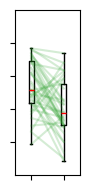

In [14]:
for di in range(3):
    day = to_day(di)
    print(day)
    plt.figure(figsize=(1, 2))
    plt.tick_params(labelleft=False, labelbottom=False)
    plt.ylim(-1, 1.5)
    plt.yticks([-0.5, 0, 0.5, 1.0])
    box_data = plt.boxplot(corr_day_100[di], sym="", medianprops={"color": "r"})

    qs = np.array([d.get_ydata() for d in box_data["whiskers"]]).reshape(-1, 4)
    ms = [d.get_ydata()[0] for d in box_data["medians"]]
    n = len(corr_day_100[di])
    for i, p in enumerate(["Pre ", "Post"]):
        q1, q1_iqr, q3, q3_iqr = qs[i]
        m = ms[i]
        print("{} (n={}) | Q1-1.5IQR: {:>7.4f}, Q1: {:>7.4f}, Median: {:>7.4f}, Q3: {:>7.4f}, Q3+1.5IQR: {:>7.4f}".format(p, n, q1_iqr, q1, m, q3, q3_iqr))
    
    plt.plot(np.array([[1,2] for _ in corr_day_100[di]]).T, corr_day_100[di].T, c="C"+str(di), alpha=0.2)
    plt.tight_layout()
    plt.savefig("figures/fig5/fig5c_{}.png".format(day))
    t_result = stats.ttest_rel(corr_day_100[di][:, 0], corr_day_100[di][:, 1])
    
    print("t-test rel | t{}={:.4f}, P={:.4f}".format(t_result.df, t_result.statistic, t_result.pvalue))
    
    plt.show()

In [15]:
width = 100
mi = 5
di = 2
t_h, k = h[mi][di].shape
t = t_h - 49
succ = np.where(beh[mi][di][:, 2] == 1)[0]
succ = succ[(succ + 49 >= width) & (succ + width < t)]
n_succ = len(succ)
n_miss = len(miss)
tmp = np.zeros((2*width+1, k))
for i in range(1,width+1):
    tmp[width-i, :] = h[mi][di][succ+49-i].mean(axis=0)
    tmp[width+i, :] = h[mi][di][succ+49+i].mean(axis=0)
tmp[width, :] = h[mi][di][succ+49].mean(axis=0)

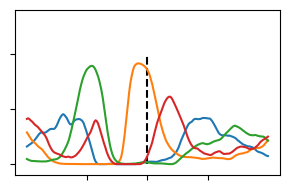

In [16]:
plt.figure(figsize=(3, 2))
plt.plot(tmp, zorder=1)
plt.vlines(x=width, ymin=0, ymax=1, color="k", linestyle="--", zorder=0)
plt.xticks([width-50, width, width+50])
plt.yticks([0, 0.5, 1.0])
plt.ylim(-0.1, 1.4)
plt.tick_params(labelleft=False, labelbottom=False)
plt.tight_layout()
plt.savefig("figures/figs7/figs7b.png")

In [17]:
with open("h5_spike.pkl", "rb") as f:
    h = pickle.load(f)

In [18]:
width = 25
save_25 = []
for mi in range(6):
    save_s = []
    for di in range(3):
        t_h, k = h[mi][di].shape
        t = t_h - 24
        mean = h[mi][di].mean(axis=0)
        std = h[mi][di].std(axis=0)
        succ = np.where(beh[mi][di][:, 2] == 1)[0]
        miss = np.where((beh[mi][di][:, 2] == 0) & (beh[mi][di][:, 1] == 1))[0]
        succ = succ[(succ + 24 >= width) & (succ + width < t)]
        miss = miss[(miss + 24 >= width) & (miss + width < t)]
        n_succ = len(succ)
        n_miss = len(miss)
        tmp = np.zeros((2*width+1, k, 2))
        for i in range(1,width+1):
            tmp[width-i, :, 0] = (h[mi][di][succ+24-i].mean(axis=0) - mean) / std
            tmp[width+i, :, 0] = (h[mi][di][succ+24+i].mean(axis=0) - mean) / std
            tmp[width-i, :, 1] = (h[mi][di][miss+24-i].mean(axis=0) - mean) / std
            tmp[width+i, :, 1] = (h[mi][di][miss+24+i].mean(axis=0) - mean) / std
        tmp[width, :, 0] = (h[mi][di][succ+24].mean(axis=0) - mean) / std
        tmp[width, :, 1] = (h[mi][di][miss+24].mean(axis=0) - mean) / std
        # to avoid cov = 0
        np.random.seed(mi * 10 + di)
        save_s.append(tmp + np.random.random(size=tmp.shape) * 1e-7)
    save_25.append(save_s)

In [19]:
width = 50
save_50 = []
for mi in range(6):
    save_s = []
    for di in range(3):
        t_h, k = h[mi][di].shape
        t = t_h - 24
        mean = h[mi][di].mean(axis=0)
        std = h[mi][di].std(axis=0)
        succ = np.where(beh[mi][di][:, 2] == 1)[0]
        miss = np.where((beh[mi][di][:, 2] == 0) & (beh[mi][di][:, 1] == 1))[0]
        succ = succ[(succ + 24 >= width) & (succ + width < t)]
        miss = miss[(miss + 24 >= width) & (miss + width < t)]
        n_succ = len(succ)
        n_miss = len(miss)
        tmp = np.zeros((2*width+1, k, 2))
        for i in range(1,width+1):
            tmp[width-i, :, 0] = (h[mi][di][succ+24-i].mean(axis=0) - mean) / std
            tmp[width+i, :, 0] = (h[mi][di][succ+24+i].mean(axis=0) - mean) / std
            tmp[width-i, :, 1] = (h[mi][di][miss+24-i].mean(axis=0) - mean) / std
            tmp[width+i, :, 1] = (h[mi][di][miss+24+i].mean(axis=0) - mean) / std
        tmp[width, :, 0] = (h[mi][di][succ+24].mean(axis=0) - mean) / std
        tmp[width, :, 1] = (h[mi][di][miss+24].mean(axis=0) - mean) / std
        save_s.append(tmp)
    save_50.append(save_s)

In [20]:
width = 100
save_100 = []
for mi in range(6):
    save_s = []
    for di in range(3):
        t_h, k = h[mi][di].shape
        t = t_h - 24
        mean = h[mi][di].mean(axis=0)
        std = h[mi][di].std(axis=0)
        succ = np.where(beh[mi][di][:, 2] == 1)[0]
        miss = np.where((beh[mi][di][:, 2] == 0) & (beh[mi][di][:, 1] == 1))[0]
        succ = succ[(succ + 24 >= width) & (succ + width < t)]
        miss = miss[(miss + 24 >= width) & (miss + width < t)]
        n_succ = len(succ)
        n_miss = len(miss)
        tmp = np.zeros((2*width+1, k, 2))
        for i in range(1,width+1):
            tmp[width-i, :, 0] = (h[mi][di][succ+24-i].mean(axis=0) - mean) / std
            tmp[width+i, :, 0] = (h[mi][di][succ+24+i].mean(axis=0) - mean) / std
            tmp[width-i, :, 1] = (h[mi][di][miss+24-i].mean(axis=0) - mean) / std
            tmp[width+i, :, 1] = (h[mi][di][miss+24+i].mean(axis=0) - mean) / std
        tmp[width, :, 0] = (h[mi][di][succ+24].mean(axis=0) - mean) / std
        tmp[width, :, 1] = (h[mi][di][miss+24].mean(axis=0) - mean) / std
        save_s.append(tmp)
    save_100.append(save_s)

In [21]:
width = 25
corr_25 = []
for mi in range(6):
    corr_s = []
    for di in range(3):
        k = save_25[mi][di].shape[1]
        tmp = np.zeros((k, 2))
        for ki in range(k):
            tmp[ki, 0] = np.corrcoef(save_25[mi][di][:width, ki, :].T)[1, 0]
            tmp[ki, 1] = np.corrcoef(save_25[mi][di][-width:, ki, :].T)[1, 0]
        corr_s.append(tmp)
    corr_25.append(corr_s)

In [22]:
width = 50
corr_50 = []
for mi in range(6):
    corr_s = []
    for di in range(3):
        k = save_50[mi][di].shape[1]
        tmp = np.zeros((k, 2))
        for ki in range(k):
            tmp[ki, 0] = np.corrcoef(save_50[mi][di][:width, ki, :].T)[1, 0]
            tmp[ki, 1] = np.corrcoef(save_50[mi][di][-width:, ki, :].T)[1, 0]
        corr_s.append(tmp)
    corr_50.append(corr_s)

In [23]:
width = 100
corr_100 = []
for mi in range(6):
    corr_s = []
    for di in range(3):
        k = save_100[mi][di].shape[1]
        tmp = np.zeros((k, 2))
        for ki in range(k):
            tmp[ki, 0] = np.corrcoef(save_100[mi][di][:width, ki, :].T)[1, 0]
            tmp[ki, 1] = np.corrcoef(save_100[mi][di][-width:, ki, :].T)[1, 0]
        corr_s.append(tmp)
    corr_100.append(corr_s)

mouse1 day1


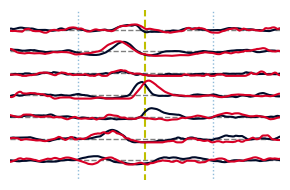

mouse1 day2


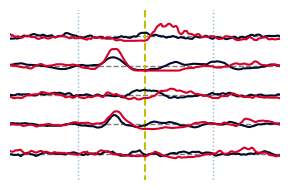

mouse1 day6


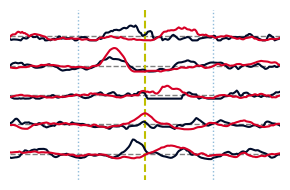

mouse2 day1


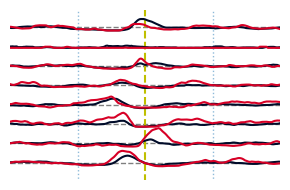

mouse2 day2


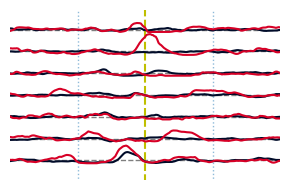

mouse2 day6


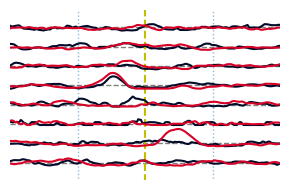

mouse3 day1


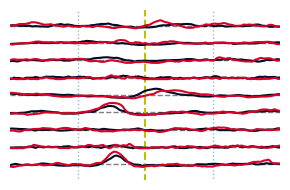

mouse3 day2


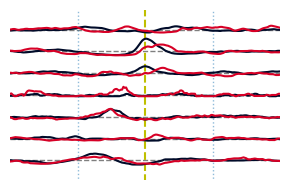

mouse3 day6


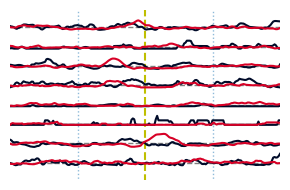

mouse4 day1


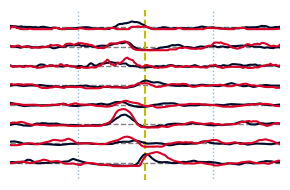

mouse4 day2


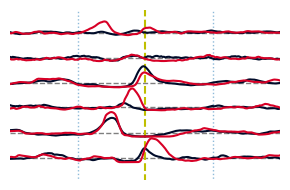

mouse4 day6


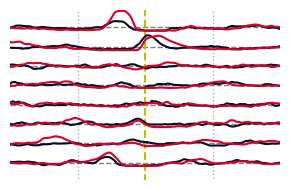

mouse5 day1


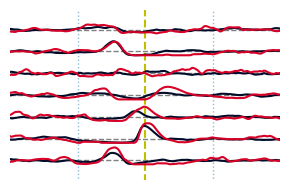

mouse5 day2


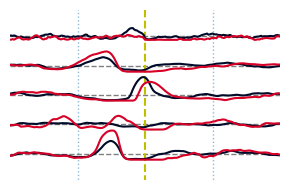

mouse5 day6


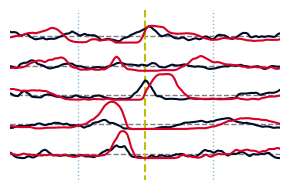

mouse6 day1


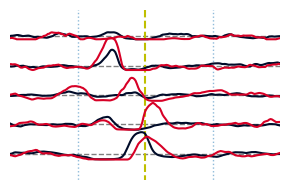

mouse6 day2


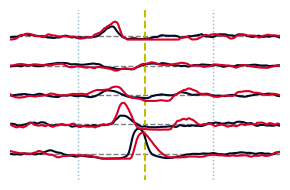

mouse6 day6


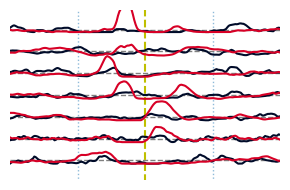

In [24]:
scale = 3
for mi in range(6):
    mouse = "mouse" + str(mi + 1)
    for di in range(3):
        day = to_day(di)
        print(mouse, day)
        tmp = save_100[mi][di].copy()
        tmp[tmp > 5] = 5
        tmp[tmp < -5] = -5
        k = tmp.shape[1]
        plt.figure(figsize=(3, 2))
        for i in range(k):
            for j, color in enumerate(["#d70026", "#000b29"]):
                plt.plot(tmp[:, i, j] - scale*i, c=color, zorder=2-j)
            plt.hlines(-scale*i, 0, 200, color="k", alpha=0.5, zorder=0, linestyles="--", linewidth=1)
        plt.xlim(0, 200)
        plt.yticks([-scale*i for i in range(k)])
        plt.ylim(-scale*(k-0.1), scale * 0.9)
        plt.vlines(100, -scale*k, scale, color="y", linestyles="--", zorder=0)
        plt.vlines(50, -scale*k, scale, color="C0", alpha=0.5, linestyles=":", linewidth=1, zorder=0)
        plt.vlines(150, -scale*k, scale, color="C0", alpha=0.5, linestyles=":", linewidth=1, zorder=0)
        plt.tick_params(labelleft=False, labelbottom=False)
        plt.axis("off")
        plt.tight_layout()
        plt.savefig("figures/figs8/figs8a_{}_{}.png".format(mouse, day))
        plt.show()

In [25]:
corr_day_25 = [np.vstack([corr_25[mi][di] for mi in range(6)]) for di in range(3)]
corr_day_25_pre = [corr_day_25[di][:, 0] for di in range(3)]
corr_day_25_post = [corr_day_25[di][:, 1] for di in range(3)]
corr_day_50 = [np.vstack([corr_50[mi][di] for mi in range(6)]) for di in range(3)]
corr_day_50_pre = [corr_day_50[di][:, 0] for di in range(3)]
corr_day_50_post = [corr_day_50[di][:, 1] for di in range(3)]
corr_day_100 = [np.vstack([corr_100[mi][di] for mi in range(6)]) for di in range(3)]
corr_day_100_pre = [corr_day_100[di][:, 0] for di in range(3)]
corr_day_100_post = [corr_day_100[di][:, 1] for di in range(3)]

day1 (n=44) | Q1-1.5IQR: -0.4399, Q1:  0.3736, Median:  0.8633, Q3:  0.9318, Q3+1.5IQR:  0.9931
day2 (n=35) | Q1-1.5IQR: -0.6997, Q1:  0.2828, Median:  0.8187, Q3:  0.9557, Q3+1.5IQR:  0.9973
day6 (n=41) | Q1-1.5IQR: -0.8776, Q1:  0.0941, Median:  0.5421, Q3:  0.7840, Q3+1.5IQR:  0.9910
one-way ANOVA | F2,117=4.1092, P=0.0188
Multiple Comparison of Means - Tukey HSD, FWER=0.05 
group1 group2 meandiff p-adj   lower   upper  reject
----------------------------------------------------
  Day1   Day2  -0.1239 0.4906 -0.3815  0.1337  False
  Day1   Day6  -0.2974 0.0138 -0.5443 -0.0505   True
  Day2   Day6  -0.1735  0.261 -0.4353  0.0882  False
----------------------------------------------------


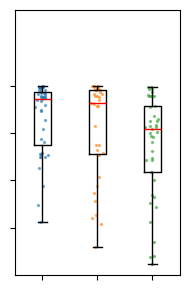

In [26]:
c = corr_day_25_pre
savename = "figures/figs8/figs8f.png"

plt.figure(figsize=(2, 3))
box_data = plt.boxplot(c, sym="", medianprops={"color": "r"})
qs = np.array([d.get_ydata() for d in box_data["whiskers"]]).reshape(-1, 4)
ms = [d.get_ydata()[0] for d in box_data["medians"]]
n = [len(ci) for ci in c]
for i in range(3):
    q1, q1_iqr, q3, q3_iqr = qs[i]
    m = ms[i]
    print("{} (n={}) | Q1-1.5IQR: {:>7.4f}, Q1: {:>7.4f}, Median: {:>7.4f}, Q3: {:>7.4f}, Q3+1.5IQR: {:>7.4f}".format(to_day(i), n[i], q1_iqr, q1, m, q3, q3_iqr))

plt.tick_params(labelleft=False, labelbottom=False)
plt.ylim(-1, 1.8)
plt.yticks([-0.5, 0, 0.5, 1.0])
for i in range(3):
    plt.scatter(np.random.normal(0, 0.05, size=n[i])+i+1, c[i], s=2, alpha=0.5)
plt.tight_layout()
plt.savefig(savename)

f_result = stats.f_oneway(c[0], c[1], c[2])
print("one-way ANOVA | F2,{}={:.4f}, P={:.4f}".format(sum(n)-3, f_result.statistic, f_result.pvalue))

df = pd.DataFrame({
    "corrcoef": np.hstack(c),
    "day": np.hstack((
        ["Day1" for _ in c[0]], 
        ["Day2" for _ in c[1]], 
        ["Day6" for _ in c[2]]))
})
tukey = pairwise_tukeyhsd(endog=df['corrcoef'],
                          groups=df['day'],
                          alpha=0.05)
print(tukey)

day1 (n=44) | Q1-1.5IQR: -0.8280, Q1: -0.2592, Median:  0.4884, Q3:  0.7545, Q3+1.5IQR:  0.9628
day2 (n=35) | Q1-1.5IQR: -0.8809, Q1: -0.2409, Median:  0.3458, Q3:  0.7432, Q3+1.5IQR:  0.9867
day6 (n=41) | Q1-1.5IQR: -0.8801, Q1: -0.2903, Median:  0.0422, Q3:  0.6648, Q3+1.5IQR:  0.9576
one-way ANOVA | F2,117=0.4816, P=0.6190
Multiple Comparison of Means - Tukey HSD, FWER=0.05
group1 group2 meandiff p-adj   lower  upper  reject
---------------------------------------------------
  Day1   Day2  -0.0706 0.8476 -0.3764 0.2352  False
  Day1   Day6  -0.1204 0.5939 -0.4134 0.1727  False
  Day2   Day6  -0.0498 0.9234 -0.3605 0.2609  False
---------------------------------------------------


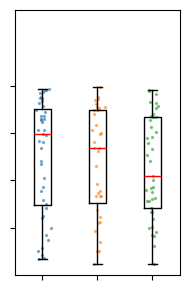

In [27]:
c = corr_day_25_post
savename = "figures/figs8/figs8g.png"

plt.figure(figsize=(2, 3))
box_data = plt.boxplot(c, sym="", medianprops={"color": "r"})
qs = np.array([d.get_ydata() for d in box_data["whiskers"]]).reshape(-1, 4)
ms = [d.get_ydata()[0] for d in box_data["medians"]]
n = [len(ci) for ci in c]
for i in range(3):
    q1, q1_iqr, q3, q3_iqr = qs[i]
    m = ms[i]
    print("{} (n={}) | Q1-1.5IQR: {:>7.4f}, Q1: {:>7.4f}, Median: {:>7.4f}, Q3: {:>7.4f}, Q3+1.5IQR: {:>7.4f}".format(to_day(i), n[i], q1_iqr, q1, m, q3, q3_iqr))

plt.tick_params(labelleft=False, labelbottom=False)
plt.ylim(-1, 1.8)
plt.yticks([-0.5, 0, 0.5, 1.0])
for i in range(3):
    plt.scatter(np.random.normal(0, 0.05, size=n[i])+i+1, c[i], s=2, alpha=0.5)
plt.tight_layout()
plt.savefig(savename)

f_result = stats.f_oneway(c[0], c[1], c[2])
print("one-way ANOVA | F2,{}={:.4f}, P={:.4f}".format(sum(n)-3, f_result.statistic, f_result.pvalue))

df = pd.DataFrame({
    "corrcoef": np.hstack(c),
    "day": np.hstack((
        ["Day1" for _ in c[0]], 
        ["Day2" for _ in c[1]], 
        ["Day6" for _ in c[2]]))
})
tukey = pairwise_tukeyhsd(endog=df['corrcoef'],
                          groups=df['day'],
                          alpha=0.05)
print(tukey)

day1 (n=44) | Q1-1.5IQR: -0.1970, Q1:  0.2811, Median:  0.7992, Q3:  0.9044, Q3+1.5IQR:  0.9891
day2 (n=35) | Q1-1.5IQR: -0.5901, Q1:  0.1678, Median:  0.6751, Q3:  0.9053, Q3+1.5IQR:  0.9948
day6 (n=41) | Q1-1.5IQR: -0.6849, Q1: -0.0309, Median:  0.3996, Q3:  0.7220, Q3+1.5IQR:  0.9556
one-way ANOVA | F2,117=4.7206, P=0.0107
Multiple Comparison of Means - Tukey HSD, FWER=0.05
group1 group2 meandiff p-adj   lower  upper  reject
---------------------------------------------------
  Day1   Day2  -0.1201 0.4665 -0.3614 0.1212  False
  Day1   Day6  -0.2983 0.0076 -0.5295 -0.067   True
  Day2   Day6  -0.1781 0.2003 -0.4233 0.0671  False
---------------------------------------------------


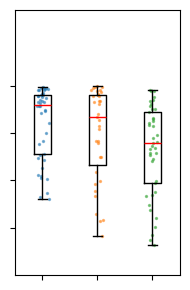

In [28]:
c = corr_day_50_pre
savename = "figures/figs8/figs8d.png"

plt.figure(figsize=(2, 3))
box_data = plt.boxplot(c, sym="", medianprops={"color": "r"})
qs = np.array([d.get_ydata() for d in box_data["whiskers"]]).reshape(-1, 4)
ms = [d.get_ydata()[0] for d in box_data["medians"]]
n = [len(ci) for ci in c]
for i in range(3):
    q1, q1_iqr, q3, q3_iqr = qs[i]
    m = ms[i]
    print("{} (n={}) | Q1-1.5IQR: {:>7.4f}, Q1: {:>7.4f}, Median: {:>7.4f}, Q3: {:>7.4f}, Q3+1.5IQR: {:>7.4f}".format(to_day(i), n[i], q1_iqr, q1, m, q3, q3_iqr))

plt.tick_params(labelleft=False, labelbottom=False)
plt.ylim(-1, 1.8)
plt.yticks([-0.5, 0, 0.5, 1.0])
for i in range(3):
    plt.scatter(np.random.normal(0, 0.05, size=n[i])+i+1, c[i], s=2, alpha=0.5)
plt.tight_layout()
plt.savefig(savename)

f_result = stats.f_oneway(c[0], c[1], c[2])
print("one-way ANOVA | F2,{}={:.4f}, P={:.4f}".format(sum(n)-3, f_result.statistic, f_result.pvalue))

df = pd.DataFrame({
    "corrcoef": np.hstack(c),
    "day": np.hstack((
        ["Day1" for _ in c[0]], 
        ["Day2" for _ in c[1]], 
        ["Day6" for _ in c[2]]))
})
tukey = pairwise_tukeyhsd(endog=df['corrcoef'],
                          groups=df['day'],
                          alpha=0.05)
print(tukey)

day1 (n=44) | Q1-1.5IQR: -0.8250, Q1: -0.1121, Median:  0.2405, Q3:  0.6259, Q3+1.5IQR:  0.9549
day2 (n=35) | Q1-1.5IQR: -0.6836, Q1: -0.1421, Median:  0.3328, Q3:  0.6728, Q3+1.5IQR:  0.9066
day6 (n=41) | Q1-1.5IQR: -0.7457, Q1: -0.1388, Median:  0.1969, Q3:  0.5485, Q3+1.5IQR:  0.8028
one-way ANOVA | F2,117=0.0199, P=0.9803
Multiple Comparison of Means - Tukey HSD, FWER=0.05
group1 group2 meandiff p-adj   lower  upper  reject
---------------------------------------------------
  Day1   Day2   0.0089  0.996 -0.2371 0.2549  False
  Day1   Day6  -0.0119 0.9921 -0.2477 0.2238  False
  Day2   Day6  -0.0208 0.9787 -0.2708 0.2291  False
---------------------------------------------------


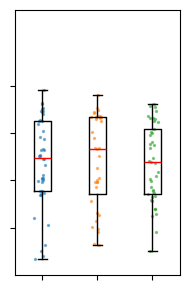

In [29]:
c = corr_day_50_post
savename = "figures/figs8/figs8e.png"

plt.figure(figsize=(2, 3))
box_data = plt.boxplot(c, sym="", medianprops={"color": "r"})
qs = np.array([d.get_ydata() for d in box_data["whiskers"]]).reshape(-1, 4)
ms = [d.get_ydata()[0] for d in box_data["medians"]]
n = [len(ci) for ci in c]
for i in range(3):
    q1, q1_iqr, q3, q3_iqr = qs[i]
    m = ms[i]
    print("{} (n={}) | Q1-1.5IQR: {:>7.4f}, Q1: {:>7.4f}, Median: {:>7.4f}, Q3: {:>7.4f}, Q3+1.5IQR: {:>7.4f}".format(to_day(i), n[i], q1_iqr, q1, m, q3, q3_iqr))

plt.tick_params(labelleft=False, labelbottom=False)
plt.ylim(-1, 1.8)
plt.yticks([-0.5, 0, 0.5, 1.0])
for i in range(3):
    plt.scatter(np.random.normal(0, 0.05, size=n[i])+i+1, c[i], s=2, alpha=0.5)
plt.tight_layout()
plt.savefig(savename)

f_result = stats.f_oneway(c[0], c[1], c[2])
print("one-way ANOVA | F2,{}={:.4f}, P={:.4f}".format(sum(n)-3, f_result.statistic, f_result.pvalue))

df = pd.DataFrame({
    "corrcoef": np.hstack(c),
    "day": np.hstack((
        ["Day1" for _ in c[0]], 
        ["Day2" for _ in c[1]], 
        ["Day6" for _ in c[2]]))
})
tukey = pairwise_tukeyhsd(endog=df['corrcoef'],
                          groups=df['day'],
                          alpha=0.05)
print(tukey)

day1 (n=44) | Q1-1.5IQR: -0.5405, Q1:  0.2104, Median:  0.6582, Q3:  0.8304, Q3+1.5IQR:  0.9586
day2 (n=35) | Q1-1.5IQR: -0.3458, Q1:  0.0086, Median:  0.5554, Q3:  0.8135, Q3+1.5IQR:  0.9838
day6 (n=41) | Q1-1.5IQR: -0.4363, Q1: -0.2012, Median:  0.1403, Q3:  0.3777, Q3+1.5IQR:  0.8935
one-way ANOVA | F2,117=9.5928, P=0.0001
Multiple Comparison of Means - Tukey HSD, FWER=0.05 
group1 group2 meandiff p-adj   lower   upper  reject
----------------------------------------------------
  Day1   Day2  -0.1082 0.4564 -0.3224  0.1061  False
  Day1   Day6  -0.3711 0.0001 -0.5764 -0.1657   True
  Day2   Day6  -0.2629 0.0135 -0.4806 -0.0452   True
----------------------------------------------------


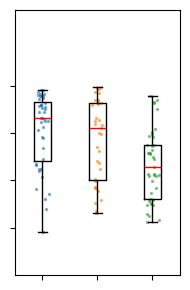

In [30]:
c = corr_day_100_pre
savename = "figures/figs8/figs8b.png"

plt.figure(figsize=(2, 3))
box_data = plt.boxplot(c, sym="", medianprops={"color": "r"})
qs = np.array([d.get_ydata() for d in box_data["whiskers"]]).reshape(-1, 4)
ms = [d.get_ydata()[0] for d in box_data["medians"]]
n = [len(ci) for ci in c]
for i in range(3):
    q1, q1_iqr, q3, q3_iqr = qs[i]
    m = ms[i]
    print("{} (n={}) | Q1-1.5IQR: {:>7.4f}, Q1: {:>7.4f}, Median: {:>7.4f}, Q3: {:>7.4f}, Q3+1.5IQR: {:>7.4f}".format(to_day(i), n[i], q1_iqr, q1, m, q3, q3_iqr))

plt.tick_params(labelleft=False, labelbottom=False)
plt.ylim(-1, 1.8)
plt.yticks([-0.5, 0, 0.5, 1.0])
for i in range(3):
    plt.scatter(np.random.normal(0, 0.05, size=n[i])+i+1, c[i], s=2, alpha=0.5)
plt.tight_layout()
plt.savefig(savename)

f_result = stats.f_oneway(c[0], c[1], c[2])
print("one-way ANOVA | F2,{}={:.4f}, P={:.4f}".format(sum(n)-3, f_result.statistic, f_result.pvalue))

df = pd.DataFrame({
    "corrcoef": np.hstack(c),
    "day": np.hstack((
        ["Day1" for _ in c[0]], 
        ["Day2" for _ in c[1]], 
        ["Day6" for _ in c[2]]))
})
tukey = pairwise_tukeyhsd(endog=df['corrcoef'],
                          groups=df['day'],
                          alpha=0.05)
print(tukey)

day1 (n=44) | Q1-1.5IQR: -0.6412, Q1: -0.0515, Median:  0.2002, Q3:  0.4974, Q3+1.5IQR:  0.8981
day2 (n=35) | Q1-1.5IQR: -0.5526, Q1: -0.1705, Median:  0.1859, Q3:  0.4010, Q3+1.5IQR:  0.7485
day6 (n=41) | Q1-1.5IQR: -0.5779, Q1: -0.1856, Median:  0.0166, Q3:  0.2869, Q3+1.5IQR:  0.7690
one-way ANOVA | F2,117=1.8154, P=0.1673
Multiple Comparison of Means - Tukey HSD, FWER=0.05
group1 group2 meandiff p-adj   lower  upper  reject
---------------------------------------------------
  Day1   Day2  -0.0583 0.7431 -0.2464 0.1299  False
  Day1   Day6  -0.1442 0.1436 -0.3245 0.0361  False
  Day2   Day6   -0.086 0.5362 -0.2771 0.1052  False
---------------------------------------------------


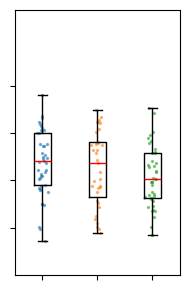

In [31]:
c = corr_day_100_post
savename = "figures/figs8/figs8c.png"

plt.figure(figsize=(2, 3))
box_data = plt.boxplot(c, sym="", medianprops={"color": "r"})
qs = np.array([d.get_ydata() for d in box_data["whiskers"]]).reshape(-1, 4)
ms = [d.get_ydata()[0] for d in box_data["medians"]]
n = [len(ci) for ci in c]
for i in range(3):
    q1, q1_iqr, q3, q3_iqr = qs[i]
    m = ms[i]
    print("{} (n={}) | Q1-1.5IQR: {:>7.4f}, Q1: {:>7.4f}, Median: {:>7.4f}, Q3: {:>7.4f}, Q3+1.5IQR: {:>7.4f}".format(to_day(i), n[i], q1_iqr, q1, m, q3, q3_iqr))

plt.tick_params(labelleft=False, labelbottom=False)
plt.ylim(-1, 1.8)
plt.yticks([-0.5, 0, 0.5, 1.0])
for i in range(3):
    plt.scatter(np.random.normal(0, 0.05, size=n[i])+i+1, c[i], s=2, alpha=0.5)
plt.tight_layout()
plt.savefig(savename)

f_result = stats.f_oneway(c[0], c[1], c[2])
print("one-way ANOVA | F2,{}={:.4f}, P={:.4f}".format(sum(n)-3, f_result.statistic, f_result.pvalue))

df = pd.DataFrame({
    "corrcoef": np.hstack(c),
    "day": np.hstack((
        ["Day1" for _ in c[0]], 
        ["Day2" for _ in c[1]], 
        ["Day6" for _ in c[2]]))
})
tukey = pairwise_tukeyhsd(endog=df['corrcoef'],
                          groups=df['day'],
                          alpha=0.05)
print(tukey)

In [32]:
with open("w_single.pkl", "rb") as f:
    w10 = pickle.load(f)

with open("w5_single.pkl", "rb") as f:
    w5 = pickle.load(f)

In [33]:
k5 = np.array([[w5[mi][di].shape[1] for di in range(3)] for mi in range(6)])
k10 = np.array([[w10[mi][di].shape[1] for di in range(3)] for mi in range(6)])

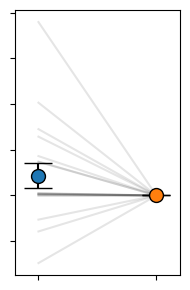

In [34]:
plt.figure(figsize=(2, 3))
k_diff_rate = ((k5 - k10) / k10).reshape(-1)
k_diff_rate.mean(), stats.sem(k_diff_rate)
np.random.seed(0)
k_diff_rate_noise = k_diff_rate + np.random.random(size=18) * 0.01
plt.plot(np.array([k_diff_rate_noise, np.zeros(18)]), color="k", alpha=0.1)
plt.xlim(-0.2, 1.2)
plt.errorbar(0, y=k_diff_rate.mean(), fmt="o", yerr=stats.sem(k_diff_rate), ecolor="black", markeredgecolor="black", color="C0", markersize=10, capsize=10, zorder=2)
plt.errorbar(1, y=0, fmt="o", yerr=0, ecolor="black", markeredgecolor="black", color="C1", markersize=10, capsize=10, zorder=2)
plt.yticks([-0.2, 0, 0.2, 0.4, 0.6, 0.8])
plt.xticks([0, 1])
plt.tick_params(labelleft=False, labelbottom=False)
plt.tight_layout()
plt.savefig("figures/figs8/figs8h.png")

In [35]:
result = stats.ttest_1samp(k_diff_rate, 0)
print("t-test one sample result: p={:.3f}".format(result.pvalue))
print("K was not changed in {}/18 decomposition".format(np.sum(k_diff_rate == 0)))

t-test one sample result: p=0.134
K was not changed in 8/18 decomposition
